# Modal Parameter Estimation from Plate IR

This notebook:
1. Loads a plate impulse response from the stripped dataset (truncated to 4s)
2. Passes it through the trained DeepSets CNF model (CPU-compatible, no GPU required)
3. Extracts predicted modal parameters (f0, sigma, gain)
4. Synthesises a new plate IR using the Kirchhoff modal model
5. Compares original and resynthesised IR

In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import torch
import soundfile as sf
import IPython.display as ipd
import matplotlib.pyplot as plt

REPO = Path().resolve()
print(f'Repo root: {REPO}')
assert (REPO / 'TaskB_CNF').exists(), \
    f'TaskB_CNF not found under {REPO} — adjust REPO path'

sys.path.insert(0, str(REPO / 'TaskB_CNF'))

from dataset import (
    compute_log_mag_fft,
    denormalise_f0, denormalise_sigma, denormalise_gain
)
from train_module import ModalFlowMatchingModule

DEVICE = 'cpu'
print(f'Using device: {DEVICE}')

Repo root: /Users/pablotablasdepaula/PycharmProjects/challenge
Using device: cpu


## 1. Load a stripped IR and truncate to 4 seconds

Loaded IR 0001: 220500 samples @ 44100 Hz (5.00s)
Truncated to 176400 samples (4.0s)
Original IR:


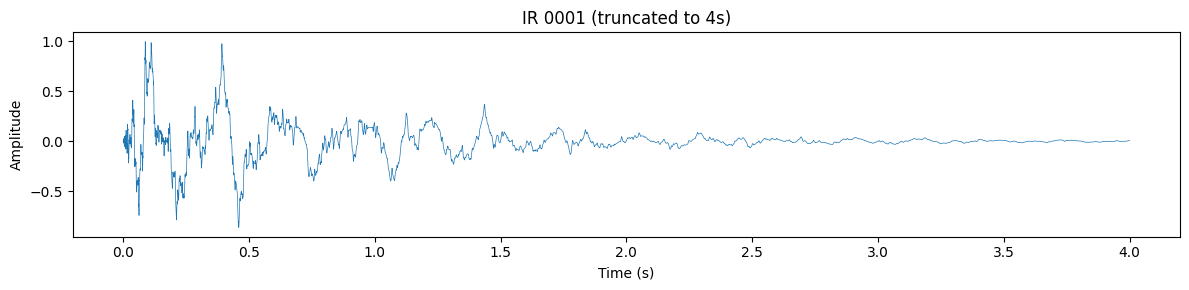

In [2]:
STRIPPED_DIR    = REPO / '2026-DATASET-STRIPPED'
IR_ID           = '0001'    # change to any available ID
NPZ_PATH        = STRIPPED_DIR / f'random_IR_{IR_ID}.npz'
TARGET_DURATION = 4.0       # seconds — model was trained on 4s IRs
N_FFT           = 8192

data    = np.load(NPZ_PATH)
ir_full = data['ir'].astype(np.float64)
sr      = int(data['sample_rate'])

print(f'Loaded IR {IR_ID}: {len(ir_full)} samples @ {sr} Hz '
      f'({len(ir_full)/sr:.2f}s)')

# Truncate to 4 seconds
n_target = int(TARGET_DURATION * sr)
ir       = ir_full[:n_target].copy()
print(f'Truncated to {len(ir)} samples ({TARGET_DURATION}s)')

# Normalise for playback
ir_norm = ir / (np.max(np.abs(ir)) + 1e-10)
print('Original IR:')
ipd.display(ipd.Audio(ir_norm, rate=sr))

t_axis = np.linspace(0, TARGET_DURATION, len(ir))
plt.figure(figsize=(12, 3))
plt.plot(t_axis, ir_norm, lw=0.5)
plt.xlabel('Time (s)'); plt.ylabel('Amplitude')
plt.title(f'IR {IR_ID} (truncated to 4s)')
plt.tight_layout(); plt.show()

## 2. Compute the log-magnitude FFT (encoder input)

Encoder input shape: (4097,)


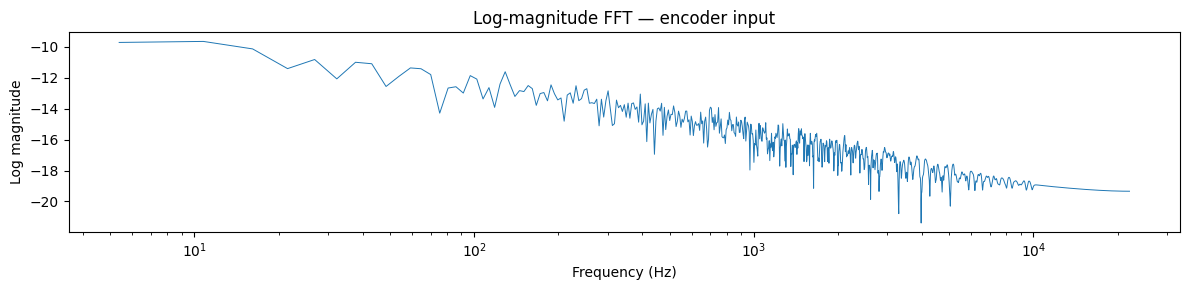

In [3]:
log_mag = compute_log_mag_fft(ir, n_fft=N_FFT)   # (N_FFT//2+1,)
print(f'Encoder input shape: {log_mag.shape}')

freqs = np.fft.rfftfreq(N_FFT, d=1.0/sr)
plt.figure(figsize=(12, 3))
plt.semilogx(freqs[1:], log_mag[1:], lw=0.7)
plt.xlabel('Frequency (Hz)'); plt.ylabel('Log magnitude')
plt.title('Log-magnitude FFT — encoder input')
plt.tight_layout(); plt.show()

## 3. Load the DeepSets checkpoint

In [5]:
CKPT_PATH = REPO / 'TaskB_CNF' / 'checkpoints' / 'deepsets.ckpt'
print(f'Loading checkpoint: {CKPT_PATH}')

model = ModalFlowMatchingModule.load_from_checkpoint(
    str(CKPT_PATH),
    map_location=DEVICE,
    weights_only=False,
)
model.eval()
model.to(DEVICE)
print('Model loaded successfully')
print(f'model_type : {model.hparams.model_type}')
print(f'd_model    : {model.hparams.d_model}')
print(f'n_layers   : {model.hparams.n_layers}')

Loading checkpoint: /Users/pablotablasdepaula/PycharmProjects/challenge/TaskB_CNF/checkpoints/deepsets.ckpt
Model loaded successfully
model_type : deepsets
d_model    : 256
n_layers   : 8


## 4. Run the flow matching sampler

We seed with a pool of Gaussian noise tokens and flow them from t=0 to t=1.
Tokens with `exists > 0.5` are treated as real modes.

In [10]:
N_NOISE_TOKENS = 30000    # enough to cover typical mode counts
VAL_STEPS      = 20      # RK4 steps — increase for better quality, decrease for speed
CFG_STRENGTH   = 2.0
EXISTS_THRESH  = 0.5

log_mag_t = torch.from_numpy(log_mag).unsqueeze(0).to(DEVICE)  # (1, N_FFT//2+1)

with torch.no_grad():
    # Encode the IR into conditioning vector z
    z = model.encoder(log_mag_t)                                # (1, d_cond)

    # Sample noise and sort by f0 slot (OT alignment)
    noise    = torch.randn(1, N_NOISE_TOKENS, 4, device=DEVICE)
    sort_idx = noise[..., 0].argsort(dim=1)
    noise    = torch.gather(noise, 1, sort_idx.unsqueeze(-1).expand_as(noise))

    # Run the ODE solver
    print(f'Running RK4 ODE ({VAL_STEPS} steps) on {N_NOISE_TOKENS} tokens...')
    pred = model._sample(z, noise, steps=VAL_STEPS, cfg=CFG_STRENGTH)

pred_np = pred[0].cpu().float().numpy()    # (N_NOISE_TOKENS, 4)

# Filter by exists flag
exists_mask = pred_np[:, 3] > EXISTS_THRESH
pred_real   = pred_np[exists_mask]

print(f'Tokens sampled:   {N_NOISE_TOKENS}')
print(f'Modes identified: {len(pred_real)}')

Running RK4 ODE (20 steps) on 30000 tokens...
Tokens sampled:   30000
Modes identified: 29996


## 5. Denormalise to physical parameters

f0    range: [3.3, 125249.8] Hz
sigma range: [0.68, 2731.28] s⁻¹
gain  range: [-2.21e-10, 2.84e-10]


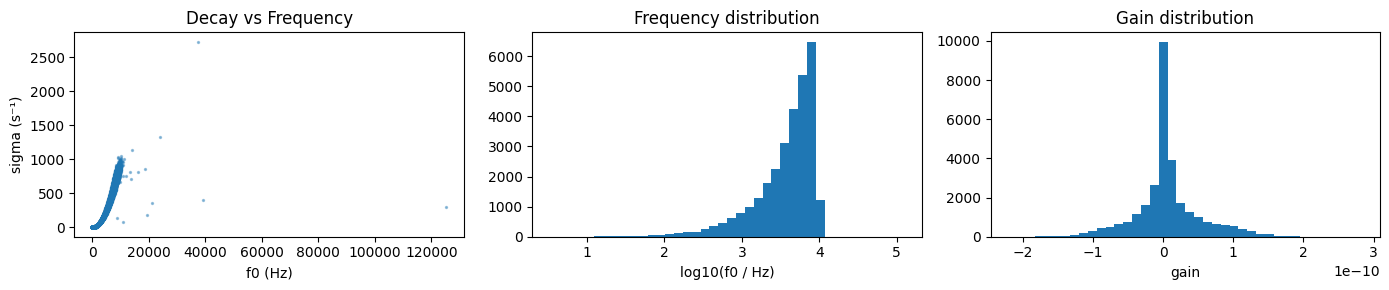

In [11]:
f0_pred    = denormalise_f0(pred_real[:, 0])
sigma_pred = denormalise_sigma(pred_real[:, 1])
gain_pred  = denormalise_gain(pred_real[:, 2])

# Sort by frequency
sort       = np.argsort(f0_pred)
f0_pred    = f0_pred[sort]
sigma_pred = sigma_pred[sort]
gain_pred  = gain_pred[sort]

print(f'f0    range: [{f0_pred.min():.1f}, {f0_pred.max():.1f}] Hz')
print(f'sigma range: [{sigma_pred.min():.2f}, {sigma_pred.max():.2f}] s⁻¹')
print(f'gain  range: [{gain_pred.min():.2e}, {gain_pred.max():.2e}]')

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].scatter(f0_pred, sigma_pred, s=2, alpha=0.4)
axes[0].set_xlabel('f0 (Hz)'); axes[0].set_ylabel('sigma (s⁻¹)')
axes[0].set_title('Decay vs Frequency')
axes[1].hist(np.log10(np.maximum(f0_pred, 1e-3)), bins=40)
axes[1].set_xlabel('log10(f0 / Hz)'); axes[1].set_title('Frequency distribution')
axes[2].hist(gain_pred, bins=40)
axes[2].set_xlabel('gain'); axes[2].set_title('Gain distribution')
plt.tight_layout(); plt.show()

## 6. Kirchhoff modal synthesis

Reconstruct the IR from the predicted modal parameters:

$$\text{IR}(t) = \sum_{k=1}^{M} b_k \cdot e^{-\sigma_k t} \cdot \sin(2\pi f_k t)$$

Synthesis is chunked to avoid materialising a large (N_samples × M_modes) matrix.

In [12]:
def kirchhoff_modal_synthesis(f0, sigma, gain, sr, duration, chunk=200):
    """
    Synthesise a plate IR from modal parameters.
    Processes modes in chunks to keep memory usage low.

    Parameters
    ----------
    f0, sigma, gain : (M,) arrays in physical units
    sr              : sample rate (Hz)
    duration        : output duration (s)
    chunk           : number of modes to process at once

    Returns
    -------
    ir_synth : (N,) float64 array
    """
    N      = int(duration * sr)
    t      = np.arange(N, dtype=np.float64) / sr
    output = np.zeros(N, dtype=np.float64)

    for start in range(0, len(f0), chunk):
        f0_c  = f0[start:start+chunk][None, :]      # (1, C)
        sig_c = sigma[start:start+chunk][None, :]
        g_c   = gain[start:start+chunk][None, :]
        t_col = t[:, None]                           # (N, 1)
        output += (g_c * np.exp(-sig_c * t_col)
                       * np.sin(2 * np.pi * f0_c * t_col)).sum(axis=1)

    return output


print(f'Synthesising {len(f0_pred)} modes...')
ir_synth = kirchhoff_modal_synthesis(
    f0_pred, sigma_pred, gain_pred,
    sr=sr, duration=TARGET_DURATION
)
print('Done.')

ir_synth_norm = ir_synth / (np.max(np.abs(ir_synth)) + 1e-10)

Synthesising 29996 modes...
Done.


## 7. Compare original and resynthesised IR

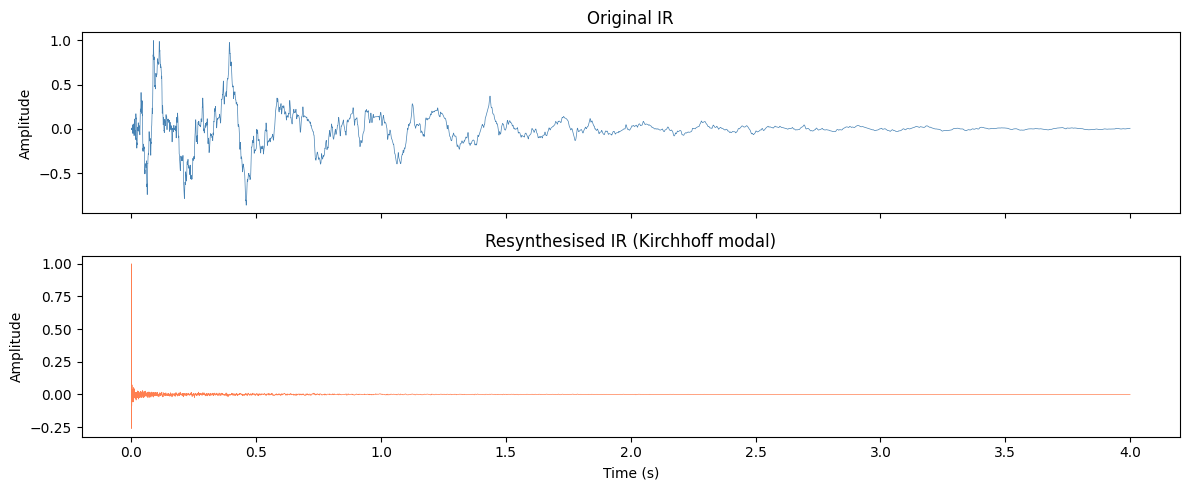

Original IR:


Resynthesised IR:


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t_axis, ir_norm,       lw=0.5, color='steelblue')
axes[0].set_ylabel('Amplitude'); axes[0].set_title('Original IR')
axes[1].plot(t_axis, ir_synth_norm, lw=0.5, color='coral')
axes[1].set_ylabel('Amplitude'); axes[1].set_title('Resynthesised IR (Kirchhoff modal)')
axes[1].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

print('Original IR:')
ipd.display(ipd.Audio(ir_norm, rate=sr))
print('Resynthesised IR:')
ipd.display(ipd.Audio(ir_synth_norm, rate=sr))

## 8. Spectral comparison

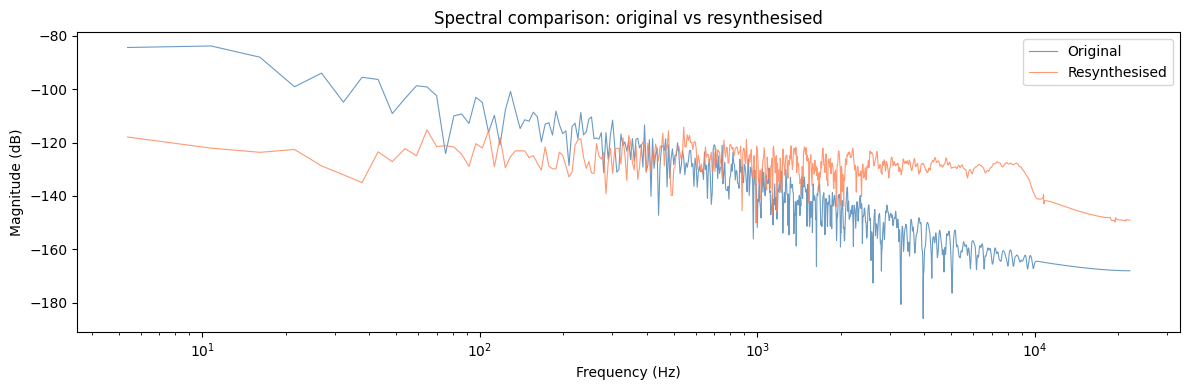

In [14]:
def log_mag_spectrum(x, n_fft, sr):
    x_pad = x[:n_fft] if len(x) >= n_fft else np.pad(x, (0, n_fft - len(x)))
    spec  = np.fft.rfft(x_pad)
    freqs = np.fft.rfftfreq(n_fft, d=1.0/sr)
    return freqs, 20 * np.log10(np.abs(spec) + 1e-10)

f_orig,  m_orig  = log_mag_spectrum(ir,       N_FFT, sr)
f_synth, m_synth = log_mag_spectrum(ir_synth, N_FFT, sr)

plt.figure(figsize=(12, 4))
plt.semilogx(f_orig[1:],  m_orig[1:],  lw=0.8, label='Original',      color='steelblue', alpha=0.8)
plt.semilogx(f_synth[1:], m_synth[1:], lw=0.8, label='Resynthesised', color='coral',     alpha=0.8)
plt.xlabel('Frequency (Hz)'); plt.ylabel('Magnitude (dB)')
plt.title('Spectral comparison: original vs resynthesised')
plt.legend(); plt.tight_layout(); plt.show()

## 9. Save resynthesised IR

In [19]:
out_path = REPO / f'resynthesised_IR_{IR_ID}.wav'
sf.write(str(out_path), ir_synth_norm.astype(np.float32), sr)
print(f'Saved: {out_path}')

Saved: /Users/pablotablasdepaula/PycharmProjects/challenge/resynthesised_IR_0001.wav


In [17]:
import scipy.signal
import numpy as np
import IPython.display as ipd

# We will use the `sr` variable (44100) already defined at the top of your notebook
def make_tri(freq, duration, sr=sr):
    """Generates a triangular wave using scipy's sawtooth (width=0.5)"""
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    return scipy.signal.sawtooth(2 * np.pi * freq * t, width=0.5)

# 1. C# Major Chord (C#4, E#4/F4, G#4)
duration_chord = 2.0
c_sharp_maj = (make_tri(277.18, duration_chord) +
               make_tri(349.23, duration_chord) +
               make_tri(415.30, duration_chord)) / 3.0

# 2. F Locrian Arpeggio (F3, Gb3, Ab3, Cb4, Eb4)
duration_note = 0.3
f_locrian_arp = np.concatenate([
    make_tri(174.61, duration_note), # F3 (Root)
    make_tri(185.00, duration_note), # Gb3 (b2)
    make_tri(207.65, duration_note), # Ab3 (b3)
    make_tri(246.94, duration_note), # Cb4/B3 (b5)
    make_tri(311.13, duration_note * 2), # Eb4 (b7) - held longer
])

# Combine into one dry track with a 1-second pause in the middle
dry_audio = np.concatenate([c_sharp_maj, np.zeros(sr), f_locrian_arp])
dry_audio /= (np.max(np.abs(dry_audio)) + 1e-10) # Normalize

print("🎧 Dry Audio (Triangular Waves):")
ipd.display(ipd.Audio(dry_audio, rate=sr))

🎧 Dry Audio (Triangular Waves):


In [22]:
import soundfile as sf
import scipy.signal
import numpy as np
import IPython.display as ipd

# 1. Read the actual audio data from the file path
TARGET_IR, ir_sr = sf.read(out_path)

# (Safety check): If the saved IR somehow has 2 channels (stereo),
# just grab the first channel so it matches your mono dry_audio.
if len(TARGET_IR.shape) > 1:
    TARGET_IR = TARGET_IR[:, 0]

# 2. Apply Plate Reverb via FFT Convolution
wet_audio = scipy.signal.fftconvolve(dry_audio, TARGET_IR, mode='full')

# 3. Normalize the output to prevent blowing out your speakers
wet_audio /= (np.max(np.abs(wet_audio)) + 1e-10)

print("🎧 Wet Audio (Chords & Arps resonating inside your deepsets plate):")
ipd.display(ipd.Audio(wet_audio, rate=sr))

🎧 Wet Audio (Chords & Arps resonating inside your deepsets plate):
